Bootstrap Mean LOS = 9.34 days
Bootstrap Standard Error = 1.12
95% CI = (7.46, 11.82)


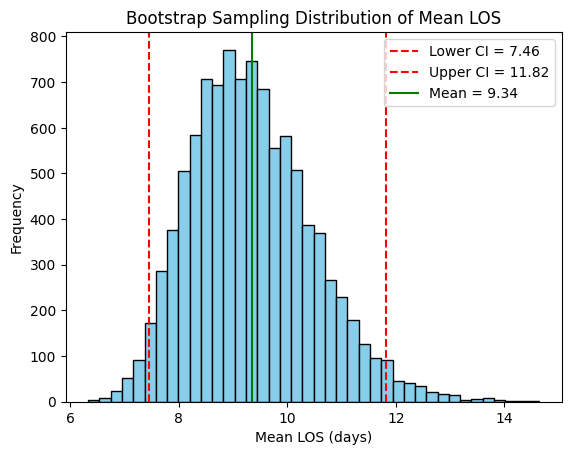

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load your dataset
df = pd.read_csv("ADMISSIONS_with_LOS.csv")

# 2. Extract the LOS column (assuming it's named 'LOS')
los = df['los_days'].dropna()

# 3. Bootstrap sampling
n_boot = 10000
boot_means = []

for _ in range(n_boot):
    sample = np.random.choice(los, size=len(los), replace=True)
    boot_means.append(np.mean(sample))

boot_means = np.array(boot_means)

# 4. Estimates
mean_los = np.mean(boot_means)
se_los = np.std(boot_means, ddof=1)
ci_lower, ci_upper = np.percentile(boot_means, [2.5, 97.5])

print(f"Bootstrap Mean LOS = {mean_los:.2f} days")
print(f"Bootstrap Standard Error = {se_los:.2f}")
print(f"95% CI = ({ci_lower:.2f}, {ci_upper:.2f})")

# 5. Histogram of bootstrap distribution
plt.hist(boot_means, bins=40, color='skyblue', edgecolor='black')
plt.axvline(ci_lower, color='red', linestyle='--', label=f'Lower CI = {ci_lower:.2f}')
plt.axvline(ci_upper, color='red', linestyle='--', label=f'Upper CI = {ci_upper:.2f}')
plt.axvline(mean_los, color='green', linestyle='-', label=f'Mean = {mean_los:.2f}')
plt.title("Bootstrap Sampling Distribution of Mean LOS")
plt.xlabel("Mean LOS (days)")
plt.ylabel("Frequency")
plt.legend()
plt.show()


MLE Mean (μ) = 9.33 days
MLE Std Dev (σ) = 12.67 days


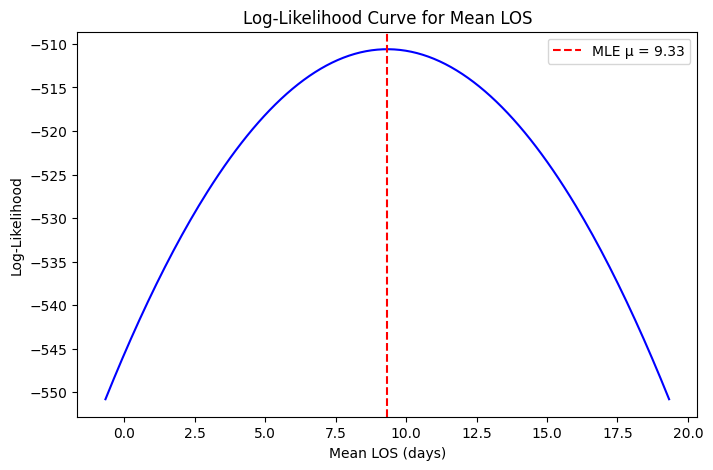

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize

# 1. Load your dataset
df = pd.read_csv("ADMISSIONS_with_LOS.csv")
los = df['los_days'].dropna().values

# 2. Define the negative log-likelihood function for Normal distribution
def neg_log_likelihood(params, data):
    mu, sigma = params
    if sigma <= 0:  # standard deviation must be positive
        return np.inf
    return -np.sum(norm.logpdf(data, loc=mu, scale=sigma))

# 3. Initial guesses (mean and std from data)
init_params = [np.mean(los), np.std(los, ddof=1)]

# 4. Optimize to find MLE estimates
result = minimize(neg_log_likelihood, init_params, args=(los,),
                  bounds=[(None, None), (1e-6, None)])  # sigma > 0

mu_mle, sigma_mle = result.x

print(f"MLE Mean (μ) = {mu_mle:.2f} days")
print(f"MLE Std Dev (σ) = {sigma_mle:.2f} days")

# 5. Plot section: log-likelihood curve for mean values
def log_likelihood(mu, data, sigma):
    return np.sum(norm.logpdf(data, loc=mu, scale=sigma))

mu_values = np.linspace(mu_mle - 10, mu_mle + 10, 200)
loglik_values = [log_likelihood(mu, los, sigma_mle) for mu in mu_values]

plt.figure(figsize=(8,5))
plt.plot(mu_values, loglik_values, color='blue')
plt.axvline(mu_mle, color='red', linestyle='--', label=f'MLE μ = {mu_mle:.2f}')
plt.title("Log-Likelihood Curve for Mean LOS")
plt.xlabel("Mean LOS (days)")
plt.ylabel("Log-Likelihood")
plt.legend()
plt.show()

T-statistic = -0.56
P-value = 0.588


<Figure size 800x500 with 0 Axes>

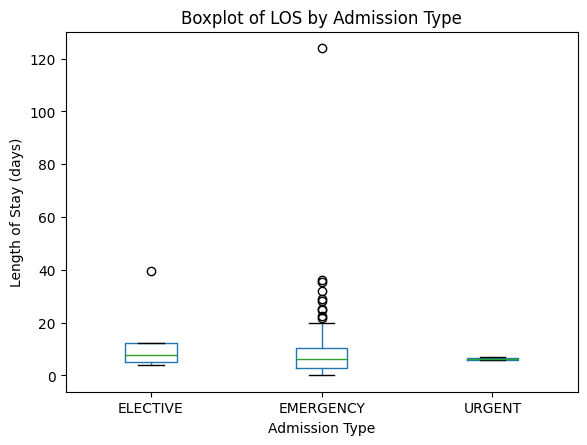

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# 1. Load your dataset
df = pd.read_csv("ADMISSIONS_with_LOS.csv")

# 2. Extract LOS values by admission type
los_emergency = df[df['admission_type'] == 'EMERGENCY']['los_days'].dropna()
los_elective = df[df['admission_type'] == 'ELECTIVE']['los_days'].dropna()

# 3. Perform two-sample t-test (Welch’s t-test by default with equal_var=False)
t_stat, p_val = ttest_ind(los_emergency, los_elective, equal_var=False)

print(f"T-statistic = {t_stat:.2f}")
print(f"P-value = {p_val:.3f}")

# 4. Boxplot comparison
plt.figure(figsize=(8,5))
df.boxplot(column='los_days', by='admission_type', grid=False)
plt.title("Boxplot of LOS by Admission Type")
plt.suptitle("")  # remove automatic title
plt.xlabel("Admission Type")
plt.ylabel("Length of Stay (days)")
plt.show()



                            OLS Regression Results                            
Dep. Variable:               los_days   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.2703
Date:                Mon, 06 Apr 2026   Prob (F-statistic):              0.604
Time:                        02:10:12   Log-Likelihood:                -503.49
No. Observations:                 127   AIC:                             1011.
Df Residuals:                     125   BIC:                             1017.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 11.6675      4

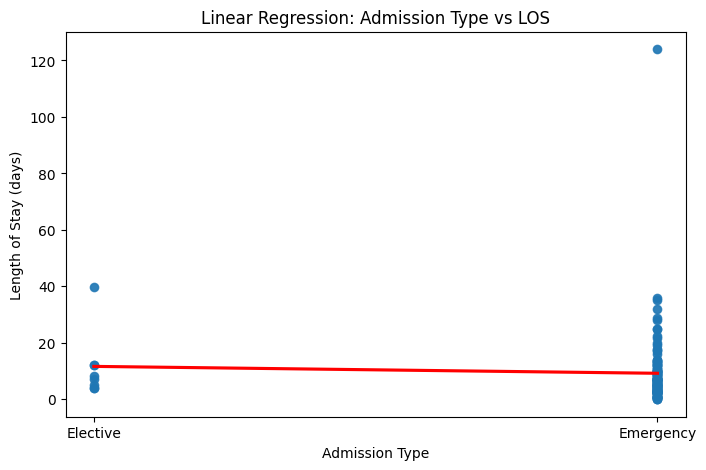

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

# 1. Load your dataset
df = pd.read_csv("ADMISSIONS_with_LOS.csv")

# 2. Encode admission type as numeric (Elective=0, Emergency=1)
df['admission_type_num'] = df['admission_type'].map({'ELECTIVE':0, 'EMERGENCY':1})

# 3. Drop rows with missing values in either LOS or admission_type_num
df_clean = df.dropna(subset=['los_days','admission_type_num'])

# 4. Define predictor (X) and response (y)
X = df_clean['admission_type_num']
y = df_clean['los_days']

# Add constant term for intercept
X = sm.add_constant(X)

# 5. Fit linear regression model
model = sm.OLS(y, X).fit()

print(model.summary())

# Extract coefficients
intercept, beta1 = model.params
print(f"Intercept (β₀) = {intercept:.2f}")
print(f"Admission Type coefficient (β₁) = {beta1:.2f}")
print(f"R² = {model.rsquared:.2f}")

# 6. Plot regression relationship
plt.figure(figsize=(8,5))
sns.scatterplot(x=df_clean['admission_type_num'], y=df_clean['los_days'], alpha=0.6)
sns.regplot(x=df_clean['admission_type_num'], y=df_clean['los_days'], ci=None, line_kws={'color':'red'})
plt.xticks([0,1], ['Elective','Emergency'])
plt.title("Linear Regression: Admission Type vs LOS")
plt.xlabel("Admission Type")
plt.ylabel("Length of Stay (days)")
plt.show()


                            OLS Regression Results                            
Dep. Variable:               los_days   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.103
Date:                Mon, 06 Apr 2026   Prob (F-statistic):              0.296
Time:                        03:43:37   Log-Likelihood:                -510.06
No. Observations:                 129   AIC:                             1024.
Df Residuals:                     127   BIC:                             1030.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              5.6515      3.679      1.

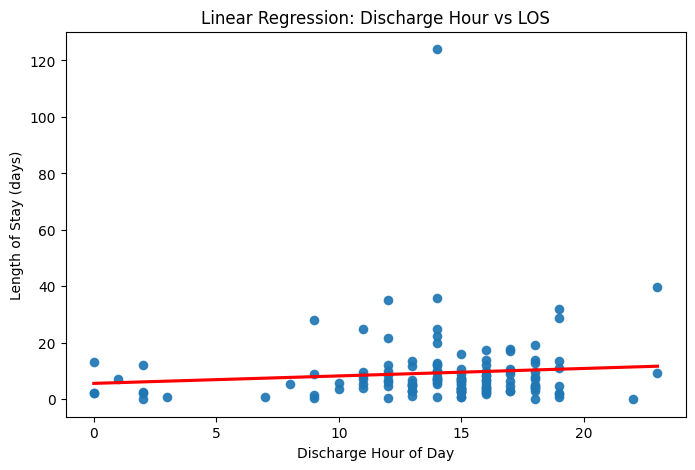

In [ ]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset
df = pd.read_csv("ADMISSIONS_with_LOS.csv")

# 2. Convert dischtime to datetime if not already
df['dischtime'] = pd.to_datetime(df['dischtime'], errors='coerce')

# 3. Example: use discharge hour as predictor
df['discharge_hour'] = df['dischtime'].dt.hour

# Drop missing values
df_clean = df.dropna(subset=['los_days','discharge_hour'])

# 4. Define predictor and response
X = df_clean[['discharge_hour']]
y = df_clean['los_days']

# Add constant term
X = sm.add_constant(X)

# 5. Fit regression model
model = sm.OLS(y, X).fit()
print(model.summary())

# 6. Plot regression relationship
plt.figure(figsize=(8,5))
sns.scatterplot(x=df_clean['discharge_hour'], y=df_clean['los_days'], alpha=0.6)
sns.regplot(x=df_clean['discharge_hour'], y=df_clean['los_days'], ci=None, line_kws={'color':'red'})
plt.title("Linear Regression: Discharge Hour vs LOS")
plt.xlabel("Discharge Hour of Day")
plt.ylabel("Length of Stay (days)")
plt.show()
